# 1. General Overview

Load dataset, ensure that it works also from another computer

In [15]:
# If any import fails, run e.g.:
# %pip install pandas plotly

from pathlib import Path
import pandas as pd
import numpy as np
import plotly.express as px

pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


In [16]:
# Works whether you run the notebook from repo root or /notebook/
cwd = Path.cwd()
root = cwd if (cwd / "data").exists() else cwd.parent

candidates = [
    root / "data" / "mind@work" / "mental_health_dataset" / "Cleaned_remote_work.csv",
    root / "data" / "mind@work" / "mental heath dataset" / "Cleaned_remote_work.csv",  # legacy typo
]

data_file = next((p for p in candidates if p.exists()), None)
assert data_file is not None, f"Dataset not found. Checked:\n- " + "\n- ".join(map(str, candidates))
data_file


PosixPath('/Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv')

In [17]:
df = pd.read_csv(data_file)
print(f"rows: {len(df):,} | cols: {df.shape[1]}")
df.head()

rows: 5,000 | cols: 19


,Age,Gender,Job_Role,Industry,Years_of_Experience,Work_Location,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Stress_Level,Mental_Health_Condition,Access_to_Mental_Health_Resources,Productivity_Change,Social_Isolation_Rating,Satisfaction_with_Remote_Work,Company_Support_for_Remote_Work,Physical_Activity,Sleep_Quality,Region
0,32,Non-binary,HR,Healthcare,13,Hybrid,47,7,2,Medium,Depression,No,Decrease,1,Unsatisfied,1,Weekly,Good,Europe
1,40,Female,Data Scientist,IT,3,Remote,52,4,1,Medium,Anxiety,No,Increase,3,Satisfied,2,Weekly,Good,Asia
2,59,Non-binary,Software Engineer,Education,22,Hybrid,46,11,5,Medium,Anxiety,No,No Change,4,Unsatisfied,5,NaN,Poor,North America
3,27,Male,Software Engineer,Finance,20,Onsite,32,8,4,High,Depression,Yes,Increase,3,Unsatisfied,3,NaN,Poor,Europe
4,49,Male,Sales,Consulting,32,Onsite,35,12,2,High,NaN,Yes,Decrease,3,Unsatisfied,3,Weekly,Average,North America


In [18]:
print("Dataset shape:", df.shape)
df.info()
df.describe()

Dataset shape: (5000, 19)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 19 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   Age                                5000 non-null   int64 
 1   Gender                             5000 non-null   object
 2   Job_Role                           5000 non-null   object
 3   Industry                           5000 non-null   object
 4   Years_of_Experience                5000 non-null   int64 
 5   Work_Location                      5000 non-null   object
 6   Hours_Worked_Per_Week              5000 non-null   int64 
 7   Number_of_Virtual_Meetings         5000 non-null   int64 
 8   Work_Life_Balance_Rating           5000 non-null   int64 
 9   Stress_Level                       5000 non-null   object
 10  Mental_Health_Condition            3804 non-null   object
 11  Access_to_Mental_Health_Resources  5000 non

,Age,Years_of_Experience,Hours_Worked_Per_Week,Number_of_Virtual_Meetings,Work_Life_Balance_Rating,Social_Isolation_Rating,Company_Support_for_Remote_Work
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,40.995000,17.810200,39.614600,7.559000,2.984200,2.993800,3.007800
std,11.296021,10.020412,11.860194,4.636121,1.410513,1.394615,1.399046
min,22.000000,1.000000,20.000000,0.000000,1.000000,1.000000,1.000000
25%,31.000000,9.000000,29.000000,4.000000,2.000000,2.000000,2.000000
50%,41.000000,18.000000,40.000000,8.000000,3.000000,3.000000,3.000000
75%,51.000000,26.000000,50.000000,12.000000,4.000000,4.000000,4.000000
max,60.000000,35.000000,60.000000,15.000000,5.000000,5.000000,5.000000


For descriptive analysis (EDA): i will leave them as object. Pandas .value_counts() and Seaborn plots work fine. But later for modelling like classification, they should have categorical as datatype.

In [46]:
df["Physical_Activity"] = df["Physical_Activity"].fillna("No Activity")
df["Mental_Health_Condition"] = df["Mental_Health_Condition"].fillna("No Condition")
# Confirm fixes
print(df.isna().sum())

Age                                  0
Gender                               0
Job_Role                             0
Industry                             0
Years_of_Experience                  0
Work_Location                        0
Hours_Worked_Per_Week                0
Number_of_Virtual_Meetings           0
Work_Life_Balance_Rating             0
Stress_Level                         0
Mental_Health_Condition              0
Access_to_Mental_Health_Resources    0
Productivity_Change                  0
Social_Isolation_Rating              0
Satisfaction_with_Remote_Work        0
Company_Support_for_Remote_Work      0
Physical_Activity                    0
Sleep_Quality                        0
Region                               0
dtype: int64


# 2. Checking any reationships between variables.

### 2.1. Realtionships between categorical variables

In [34]:
def load_cleaned_remote_work():
    root = Path.cwd()
    if not (root / "data").exists():
        root = root.parent  # if running from /notebook

    candidates = [
        root / "data/mind@work/mental_health_dataset/Cleaned_remote_work.csv",
        root / "data/mind@work/mental heath dataset/Cleaned_remote_work.csv",  # legacy folder name with a space
    ]
    for p in candidates:
        if p.exists():
            print(f"Loading: {p}")
            return pd.read_csv(p)

    # fallback: search anywhere under the repo
    hits = list(root.rglob("Cleaned_remote_work.csv"))
    if hits:
        print(f"Loading (found by search): {hits[0]}")
        return pd.read_csv(hits[0])

    raise FileNotFoundError(
        f"Could not find Cleaned_remote_work.csv.\nTried:\n- " +
        "\n- ".join(map(str, candidates)) +
        "\nAnd a recursive search under: " + str(root)
    )

# ---- restore df as a DataFrame
df = load_cleaned_remote_work()
print(type(df), df.shape)   # should show <class 'pandas.core.frame.DataFrame'>

Loading: /Users/huongle/Documents/GitHub/Mind_At_Work_Website/data/mind@work/mental_health_dataset/Cleaned_remote_work.csv
<class 'pandas.core.frame.DataFrame'> (5000, 19)


In [35]:
import pandas as pd
from itertools import combinations
from scipy.stats import chi2_contingency

def scan_categorical_relationships(df_in, alpha=0.05):
    if not isinstance(df_in, pd.DataFrame):
        raise TypeError(f"Expected a pandas DataFrame, got {type(df_in)}. "
                        "Did you overwrite `df` earlier?")
    df = df_in.copy()

    # pick categorical-like columns
    cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns.tolist()
    results = []
    for col1, col2 in combinations(cat_cols, 2):
        ct = pd.crosstab(df[col1].fillna("Missing"), df[col2].fillna("Missing"))
        if ct.shape[0] > 1 and ct.shape[1] > 1:
            chi2, p, dof, _ = chi2_contingency(ct)
            results.append({
                "Var1": col1, "Var2": col2,
                "Chi2": chi2, "dof": dof, "p_value": p,
                "Significant": p < alpha
            })

    res = pd.DataFrame(results)
    return res.sort_values("p_value") if not res.empty else res


In [36]:
chi_results = scan_categorical_relationships(df)
chi_results.head(10)             # top 10 by p-value
sig = chi_results[chi_results.p_value < 0.05]
sig.head(10)


,Var1,Var2,Chi2,dof,p_value,Significant
14,Job_Role,Mental_Health_Condition,51.281227,18,0.000048,True
34,Work_Location,Satisfaction_with_Remote_Work,14.488583,4,0.005888,True
39,Stress_Level,Access_to_Mental_Health_Resources,7.224236,2,0.026995,True
8,Gender,Physical_Activity,13.629166,6,0.034064,True
58,Productivity_Change,Sleep_Quality,9.962953,4,0.041056,True
51,Access_to_Mental_Health_Resources,Productivity_Change,6.272912,2,0.043436,True


In [37]:
from itertools import combinations
from scipy.stats import chi2_contingency

def scan_categorical_relationships(df, alpha=0.05):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    results = []

    for col1, col2 in combinations(cat_cols, 2):
        ct = pd.crosstab(df[col1], df[col2])
        if ct.shape[0] > 1 and ct.shape[1] > 1:  # skip trivial tables
            chi2, p, dof, _ = chi2_contingency(ct)
            results.append((col1, col2, chi2, dof, p, p < alpha))
    
    results_df = pd.DataFrame(results, 
                              columns=["Var1", "Var2", "Chi2", "dof", "p_value", "Significant"])
    return results_df.sort_values("p_value")

# Run it
chi_results = scan_categorical_relationships(df)
print(chi_results.head(10))  # show top 10 strongest relationships

                                 Var1                               Var2       Chi2  dof   p_value  Significant
34                      Work_Location      Satisfaction_with_Remote_Work  14.488583    4  0.005888         True
39                       Stress_Level  Access_to_Mental_Health_Resources   7.224236    2  0.026995         True
58                Productivity_Change                      Sleep_Quality   9.962953    4  0.041056         True
46            Mental_Health_Condition                Productivity_Change   9.842172    4  0.043172         True
51  Access_to_Mental_Health_Resources                Productivity_Change   6.272912    2  0.043436         True
11                           Job_Role                           Industry  50.839641   36  0.051554        False
2                              Gender                      Work_Location  11.561535    6  0.072496        False
8                              Gender                  Physical_Activity   6.614642    3  0.085249      

Then, i want to show these realtionships in chart:

/var/folders/7m/_vb5phg50tdbns11bkg8wskr0000gn/T/ipykernel_54705/1870455483.py:39: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



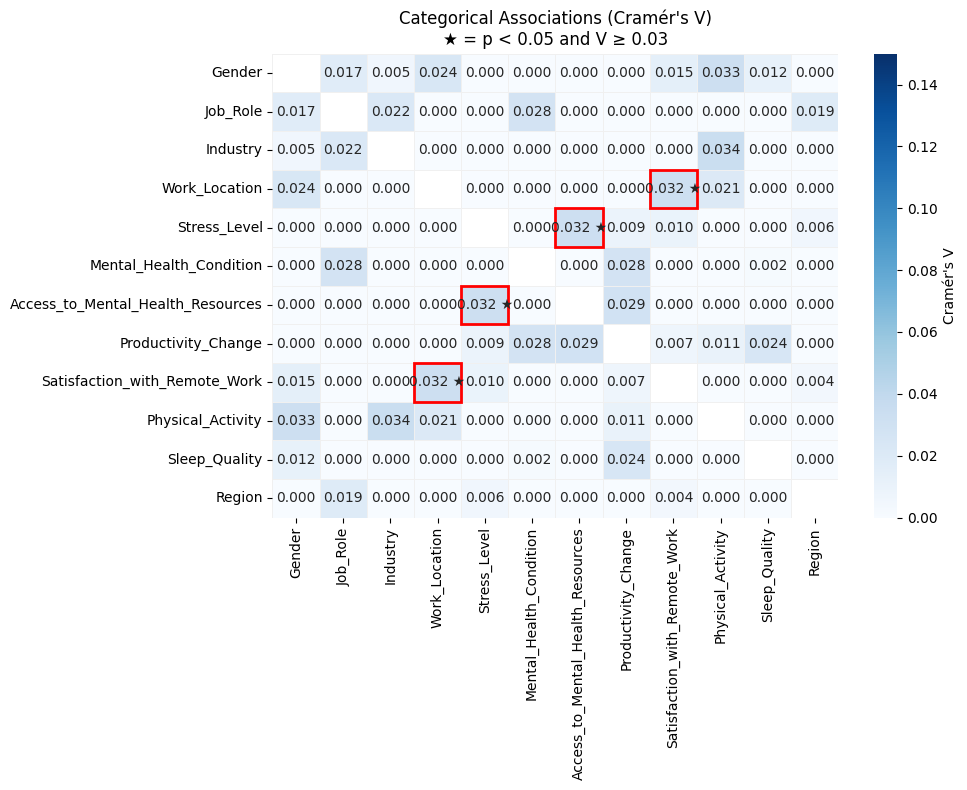

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from itertools import combinations

def cramers_v_and_p(x, y):
    ct = pd.crosstab(x, y)
    chi2, p, _, _ = chi2_contingency(ct)
    n = ct.values.sum()
    r, k = ct.shape
    phi2 = chi2 / n
    # bias-corrected Cramér's V
    phi2_corr = max(0, phi2 - ((k-1)*(r-1)) / (n-1))
    r_corr = r - ((r-1)**2) / (n-1)
    k_corr = k - ((k-1)**2) / (n-1)
    v = np.sqrt(phi2_corr / max(1e-12, min((k_corr-1), (r_corr-1))))
    return v, p

# --- build matrices
alpha = 0.05          # significance threshold
min_v = 0.03          # optional: “meaningful” effect size threshold

cat_cols = df.select_dtypes(include=["object", "category"]).columns
V = pd.DataFrame(np.nan, index=cat_cols, columns=cat_cols, dtype=float)
P = pd.DataFrame(np.nan, index=cat_cols, columns=cat_cols, dtype=float)

for a, b in combinations(cat_cols, 2):
    v, p = cramers_v_and_p(df[a], df[b])
    V.loc[a, b] = V.loc[b, a] = v
    P.loc[a, b] = P.loc[b, a] = p

# keep diagonal blank
np.fill_diagonal(V.values, np.nan)

# annotation text: value + star if significant & meaningful
annot = V.copy()
annot_text = annot.applymap(lambda x: "" if pd.isna(x) else f"{x:.3f}")
sig = (P < alpha) & (V >= min_v)
for i, row in enumerate(annot_text.index):
    for j, col in enumerate(annot_text.columns):
        if sig.loc[row, col]:
            annot_text.loc[row, col] = annot_text.loc[row, col] + " ★"

# --- plot
plt.figure(figsize=(10, 8))
ax = sns.heatmap(
    V, cmap="Blues", vmin=0, vmax=max(0.15, np.nanmax(V)),
    annot=annot_text, fmt="", cbar_kws={"label": "Cramér's V"},
    linewidths=0.5, linecolor="#f0f0f0"
)
ax.set_title("Categorical Associations (Cramér's V)\n★ = p < 0.05 and V ≥ {:.02f}".format(min_v))

# draw red boxes around highlighted cells (without hiding others)
for (i, row) in enumerate(V.index):
    for (j, col) in enumerate(V.columns):
        if sig.loc[row, col]:
            rect = plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="red", linewidth=2)
            ax.add_patch(rect)

plt.tight_layout()
plt.show()


### 2.2. Categorical ↔ Numeric (box/violin + ANOVA/Kruskal)

In [39]:
from scipy.stats import f_oneway, kruskal

def scan_cat_num_relationships(df, alpha=0.05):
    cat_cols = df.select_dtypes(include=["object", "category"]).columns
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    results = []

    for cat in cat_cols:
        for num in num_cols:
            groups = [g[num].dropna().values for _, g in df.groupby(cat)]
            if len(groups) > 1:  # skip if only one category
                # ANOVA (parametric)
                try:
                    fstat, p_anova = f_oneway(*groups)
                except:
                    p_anova = None
                # Kruskal-Wallis (nonparametric)
                try:
                    hstat, p_kruskal = kruskal(*groups)
                except:
                    p_kruskal = None
                
                results.append((cat, num, p_anova, p_kruskal))
    
    results_df = pd.DataFrame(results, columns=["Categorical", "Numeric", "ANOVA_p", "Kruskal_p"])
    
    # Add significance flags
    results_df["ANOVA_Significant"] = results_df["ANOVA_p"] < alpha
    results_df["Kruskal_Significant"] = results_df["Kruskal_p"] < alpha
    
    return results_df.sort_values("Kruskal_p")

# Run it
cat_num_results = scan_cat_num_relationships(df)
print(cat_num_results.head(10))  # show top 10 strongest

                          Categorical                     Numeric   ANOVA_p  Kruskal_p  ANOVA_Significant  \
24                      Work_Location  Number_of_Virtual_Meetings  0.007912   0.008139               True   
5                              Gender     Social_Isolation_Rating  0.017928   0.017263               True   
43  Access_to_Mental_Health_Resources         Years_of_Experience  0.023293   0.022648               True   
65                  Physical_Activity       Hours_Worked_Per_Week  0.047804   0.047819               True   
68                  Physical_Activity     Social_Isolation_Rating  0.060332   0.060647              False   
8                            Job_Role         Years_of_Experience  0.070227   0.072924              False   
33                       Stress_Level     Social_Isolation_Rating  0.082189   0.081565              False   
18                           Industry    Work_Life_Balance_Rating  0.082995   0.082393              False   
32                 

### 2.3. Numeric to Numeric 

In [40]:
from scipy.stats import pearsonr, spearmanr

def scan_num_num_relationships(df, alpha=0.05):
    num_cols = df.select_dtypes(include=["int64", "float64"]).columns
    results = []

    for i in range(len(num_cols)):
        for j in range(i+1, len(num_cols)):  # avoid duplicates
            col1, col2 = num_cols[i], num_cols[j]
            x, y = df[col1].dropna(), df[col2].dropna()
            min_len = min(len(x), len(y))
            if min_len > 2:  # need data
                # Pearson (linear correlation)
                r_pearson, p_pearson = pearsonr(df[col1], df[col2])
                # Spearman (rank-based, non-linear)
                r_spearman, p_spearman = spearmanr(df[col1], df[col2])
                results.append((col1, col2, r_pearson, p_pearson, r_spearman, p_spearman))
    
    results_df = pd.DataFrame(results, columns=[
        "Var1", "Var2", "Pearson_r", "Pearson_p", "Spearman_r", "Spearman_p"
    ])
    results_df["Pearson_Significant"] = results_df["Pearson_p"] < alpha
    results_df["Spearman_Significant"] = results_df["Spearman_p"] < alpha
    return results_df.sort_values("Pearson_p")

# Run it
num_num_results = scan_num_num_relationships(df)
print(num_num_results.head(10))

                          Var1                             Var2  Pearson_r  Pearson_p  Spearman_r  Spearman_p  \
4                          Age          Social_Isolation_Rating  -0.024992   0.077225   -0.025038    0.076681   
5                          Age  Company_Support_for_Remote_Work   0.023673   0.094185    0.023641    0.094627   
7          Years_of_Experience       Number_of_Virtual_Meetings   0.019043   0.178188    0.018940    0.180551   
6          Years_of_Experience            Hours_Worked_Per_Week  -0.018537   0.190015   -0.018678    0.186663   
3                          Age         Work_Life_Balance_Rating   0.017697   0.210867    0.017235    0.223045   
20     Social_Isolation_Rating  Company_Support_for_Remote_Work   0.017659   0.211858    0.017653    0.212024   
19    Work_Life_Balance_Rating  Company_Support_for_Remote_Work  -0.012913   0.361303   -0.013084    0.354990   
15  Number_of_Virtual_Meetings         Work_Life_Balance_Rating   0.007285   0.606528    0.00720

=> Numeric features in your dataset don’t strongly explain each other — they are relatively independent.

# 3. Interaction between multiple categorical variables

How stress levels (High, Medium, Low) differ across job roles, split by work location (Remote/Hybrid/Onsite)?

<Figure size 1000x600 with 0 Axes>

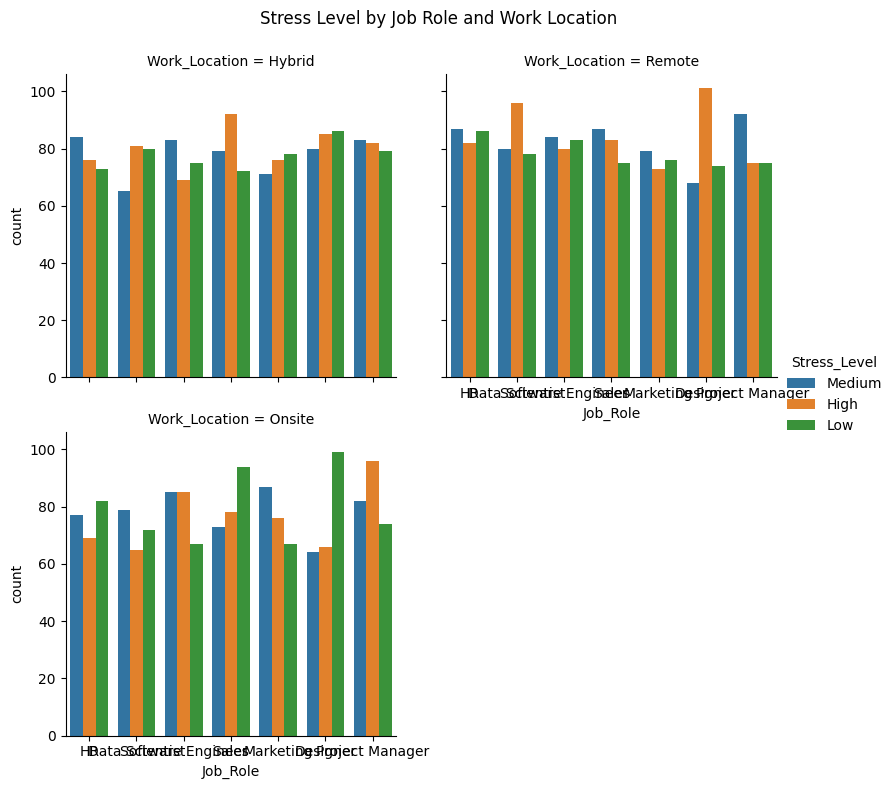

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
sns.catplot(
    data=df, x="Job_Role", hue="Stress_Level", col="Work_Location",
    kind="count", col_wrap=2, height=4
)
plt.subplots_adjust(top=0.9)
plt.suptitle("Stress Level by Job Role and Work Location")
plt.show()